In [64]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv("estadistica_datos_brutos.csv")

In [66]:
del df["dd"]
df.columns=["Horas de uso de redes sociales","rendimiento académico"]
df = df.drop([0,1]).reset_index(drop=True)
df["Horas de uso de redes sociales"] = pd.to_numeric(arg=df["Horas de uso de redes sociales"], errors="coerce",downcast="integer")
df["rendimiento académico"] = pd.to_numeric(arg=df["rendimiento académico"],errors="raise",downcast="integer")
df.columns = df.columns.str.replace(" ","_")

# Resumen inicial de los datos

En esta sección se revisa la estructura del conjunto de datos y se preparan las variables para el análisis estadístico. Se verifica que las columnas sean correctas y que los valores estén en el formato adecuado.


In [71]:
df.describe()

,Horas_de_uso_de_redes_sociales,rendimiento_académico
count,490.000000,490.000000
mean,4.473469,7.077551
std,2.243899,0.842449
min,0.000000,4.000000
25%,3.000000,7.000000
50%,4.000000,7.000000
75%,6.000000,8.000000
max,12.000000,10.000000


# Tabla de frecuencia

Esta tabla muestra la distribución del tiempo en redes sociales. Se incluyen la frecuencia absoluta, la frecuencia acumulada y los porcentajes para ver con claridad cómo se relacionan los valores con el total de estudiantes.


In [68]:
# Tabla de Frecuencia
tabla_freq = df["Horas_de_uso_de_redes_sociales"].value_counts().sort_index().reset_index()
tabla_freq.columns = ["x", "f"]

# Calcular frecuencia acumulada (F)
tabla_freq["F"] = tabla_freq["f"].cumsum()

# Calcular frecuencia relativa (fr)
tabla_freq["fr"] = tabla_freq["f"] / tabla_freq["f"].sum()

# Calcular frecuencia relativa acumulada (Fr)
tabla_freq["Fr"] = tabla_freq["fr"].cumsum()

# Calcular porcentaje (p%)
tabla_freq["p%"] = tabla_freq["fr"] * 100

# Calcular porcentaje acumulado (P%)
tabla_freq["P%"] = tabla_freq["Fr"] * 100

# Redondear a 2 decimales para mejor visualización
tabla_freq["fr"] = tabla_freq["fr"].round(4)
tabla_freq["Fr"] = tabla_freq["Fr"].round(4)
tabla_freq["p%"] = tabla_freq["p%"].round(2)
tabla_freq["P%"] = tabla_freq["P%"].round(2)

print("TABLA DE FRECUENCIA")
print("=" * 100)
print(tabla_freq.to_string(index=False))
print("=" * 100)
tabla_freq

TABLA DE FRECUENCIA
 x   f   F     fr     Fr    p%     P%
 0  11  11 0.0224 0.0224  2.24   2.24
 1  18  29 0.0367 0.0592  3.67   5.92
 2  52  81 0.1061 0.1653 10.61  16.53
 3 102 183 0.2082 0.3735 20.82  37.35
 4  92 275 0.1878 0.5612 18.78  56.12
 5  81 356 0.1653 0.7265 16.53  72.65
 6  44 400 0.0898 0.8163  8.98  81.63
 7  45 445 0.0918 0.9082  9.18  90.82
 8  17 462 0.0347 0.9429  3.47  94.29
 9  14 476 0.0286 0.9714  2.86  97.14
10   7 483 0.0143 0.9857  1.43  98.57
11   4 487 0.0082 0.9939  0.82  99.39
12   3 490 0.0061 1.0000  0.61 100.00


,x,f,F,fr,Fr,p%,P%
0,0,11,11,0.0224,0.0224,2.24,2.24
1,1,18,29,0.0367,0.0592,3.67,5.92
2,2,52,81,0.1061,0.1653,10.61,16.53
3,3,102,183,0.2082,0.3735,20.82,37.35
4,4,92,275,0.1878,0.5612,18.78,56.12
5,5,81,356,0.1653,0.7265,16.53,72.65
6,6,44,400,0.0898,0.8163,8.98,81.63
7,7,45,445,0.0918,0.9082,9.18,90.82
8,8,17,462,0.0347,0.9429,3.47,94.29
9,9,14,476,0.0286,0.9714,2.86,97.14


# Medidas de centralización y dispersión

En esta sección se calculan las medidas principales de tendencia central y dispersión para las dos variables. Estas métricas permiten comparar la estabilidad del rendimiento académico con la variabilidad del uso de redes sociales.


In [72]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Seleccionar variables para análisis
x = df["Horas_de_uso_de_redes_sociales"]
y = df["rendimiento_académico"]

print("\n" + "="*80)
print("MEDIDAS DE CENTRALIZACIÓN Y DISPERSIÓN".center(80))
print("="*80 + "\n")

# CENTRALIZACIÓN
medidas_cent = {
    'Medida': ['Media', 'Mediana', 'Moda', 'Rango Medio'],
    'Horas de Redes Sociales': [x.mean(), x.median(), x.mode()[0], (x.max() + x.min()) / 2],
    'Rendimiento Académico': [y.mean(), y.median(), y.mode()[0], (y.max() + y.min()) / 2]
}

df_cent = pd.DataFrame(medidas_cent)
print("MEDIDAS DE CENTRALIZACIÓN:")
print("-" * 80)
print(df_cent.to_string(index=False))
print()

# DISPERSIÓN
medidas_disp = {
    'Medida': ['Rango', 'Varianza', 'Desv. Estándar', 'Coef. Variación (%)', 'RIC'],
    'Horas de Redes Sociales': [
        x.max() - x.min(),
        x.var(),
        x.std(),
        (x.std() / x.mean()) * 100,
        x.quantile(0.75) - x.quantile(0.25)
    ],
    'Rendimiento Académico': [
        y.max() - y.min(),
        y.var(),
        y.std(),
        (y.std() / y.mean()) * 100,
        y.quantile(0.75) - y.quantile(0.25)
    ]
}

df_disp = pd.DataFrame(medidas_disp)
print("MEDIDAS DE DISPERSIÓN:")
print("-" * 80)
for idx, row in df_disp.iterrows():
    print(f"{row['Medida']:.<25} X: {row['Horas de Redes Sociales']:>12.4f}  |  Y: {row['Rendimiento Académico']:>12.4f}")
print()

# CUARTILES Y PERCENTILES
print("CUARTILES Y PERCENTILES:")
print("-" * 80)
percentiles_data = {
    'Percentil': ['Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)', 'P10', 'P90'],
    'Horas de Redes Sociales': [x.quantile(0.25), x.quantile(0.50), x.quantile(0.75), x.quantile(0.10), x.quantile(0.90)],
    'Rendimiento Académico': [y.quantile(0.25), y.quantile(0.50), y.quantile(0.75), y.quantile(0.10), y.quantile(0.90)]
}

df_perc = pd.DataFrame(percentiles_data)
print(df_perc.to_string(index=False))
print()

# ASIMETRÍA Y CURTOSIS
print("FORMA DE LA DISTRIBUCIÓN:")
print("-" * 80)
asimetria_x = stats.skew(x)
curtosis_x = stats.kurtosis(x)
asimetria_y = stats.skew(y)
curtosis_y = stats.kurtosis(y)

print(f"Asimetría (Skewness):")
print(f"  Horas de Redes Sociales: {asimetria_x:>12.4f}", end="")
print(f"  {'(Sesgada a derecha)' if asimetria_x > 0 else '(Sesgada a izquierda)' if asimetria_x < 0 else '(Simétrica)'}")
print(f"  Rendimiento Académico:   {asimetria_y:>12.4f}", end="")
print(f"  {'(Sesgada a derecha)' if asimetria_y > 0 else '(Sesgada a izquierda)' if asimetria_y < 0 else '(Simétrica)'}")
print()
print(f"Curtosis (Kurtosis):")
print(f"  Horas de Redes Sociales: {curtosis_x:>12.4f}", end="")
print(f"  {'(Leptocúrtica)' if curtosis_x > 0 else '(Platicúrtica)' if curtosis_x < 0 else '(Mesocúrtica)'}")
print(f"  Rendimiento Académico:   {curtosis_y:>12.4f}", end="")
print(f"  {'(Leptocúrtica)' if curtosis_y > 0 else '(Platicúrtica)' if curtosis_y < 0 else '(Mesocúrtica)'}")
print()

# ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL
print("="*80)
print("ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL".center(80))
print("="*80 + "\n")

# Correlación de Pearson
corr_pearson, p_value_pearson = stats.pearsonr(x, y)
print("CORRELACIÓN DE PEARSON:")
print("-" * 80)
print(f"Coeficiente de Correlación (r): {corr_pearson:.6f}")
print(f"P-valor: {p_value_pearson:.6e}")
print(f"Significancia: {'Significativa' if p_value_pearson < 0.05 else 'No significativa'} (α = 0.05)")
print(f"Interpretación: Correlación {'Muy fuerte' if abs(corr_pearson) > 0.9 else 'Fuerte' if abs(corr_pearson) > 0.7 else 'Moderada' if abs(corr_pearson) > 0.5 else 'Débil' if abs(corr_pearson) > 0.3 else 'Muy débil'} {'negativa' if corr_pearson < 0 else 'positiva'}")
print()

# Correlación de Spearman
corr_spearman, p_value_spearman = stats.spearmanr(x, y)
print("CORRELACIÓN DE SPEARMAN (Rangos):")
print("-" * 80)
print(f"Coeficiente de Correlación (ρ): {corr_spearman:.6f}")
print(f"P-valor: {p_value_spearman:.6e}")
print()

# Regresión Lineal
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
print("REGRESIÓN LINEAL: y = a + b*x")
print("-" * 80)
print(f"Pendiente (b):               {slope:>12.6f}")
print(f"Intersección (a):            {intercept:>12.6f}")
print(f"Coeficiente de Determinación (R²): {r_value**2:>12.6f}")
print(f"Error Estándar:              {std_err:>12.6f}")
print(f"P-valor:                     {p_value_reg:>12.6e}")
print()
print("ECUACIÓN DE REGRESIÓN:")
print(f"  Rendimiento Académico = {intercept:.4f} + {slope:.4f} × (Horas de Redes Sociales)")
print()

# Predicciones y residuos
y_pred = intercept + slope * x
residuos = y - y_pred
print("ANÁLISIS DE RESIDUOS:")
print("-" * 80)
print(f"Error Cuadrático Medio (ECM): {(residuos**2).mean():.6f}")
print(f"Raíz del ECM (RMSE):          {np.sqrt((residuos**2).mean()):.6f}")
print(f"Error Absoluto Medio (MAE):   {np.abs(residuos).mean():.6f}")
print()

# Test de normalidad de residuos
stat_normality, p_normality = stats.shapiro(residuos)
print("TEST DE NORMALIDAD DE RESIDUOS (Shapiro-Wilk):")
print("-" * 80)
print(f"Estadístico: {stat_normality:.6f}")
print(f"P-valor: {p_normality:.6e}")
print(f"Residuos: {'Distribuyen normalmente' if p_normality > 0.05 else 'NO distribuyen normalmente'} (α = 0.05)")
print()

print("="*80)



                     MEDIDAS DE CENTRALIZACIÓN Y DISPERSIÓN                     

MEDIDAS DE CENTRALIZACIÓN:
--------------------------------------------------------------------------------
     Medida  Horas de Redes Sociales  Rendimiento Académico
      Media                 4.473469               7.077551
    Mediana                 4.000000               7.000000
       Moda                 3.000000               7.000000
Rango Medio                 6.000000               7.000000

MEDIDAS DE DISPERSIÓN:
--------------------------------------------------------------------------------
Rango.................... X:      12.0000  |  Y:       6.0000
Varianza................. X:       5.0351  |  Y:       0.7097
Desv. Estándar........... X:       2.2439  |  Y:       0.8424
Coef. Variación (%)...... X:      50.1601  |  Y:      11.9031
RIC...................... X:       3.0000  |  Y:       1.0000

CUARTILES Y PERCENTILES:
--------------------------------------------------------------------

# Correlación y regresión lineal

En esta sección se analiza la relación entre las horas de uso de redes sociales y el rendimiento académico. Se calcula la correlación, se ajusta un modelo lineal y se evalúa la calidad del ajuste con los residuos.


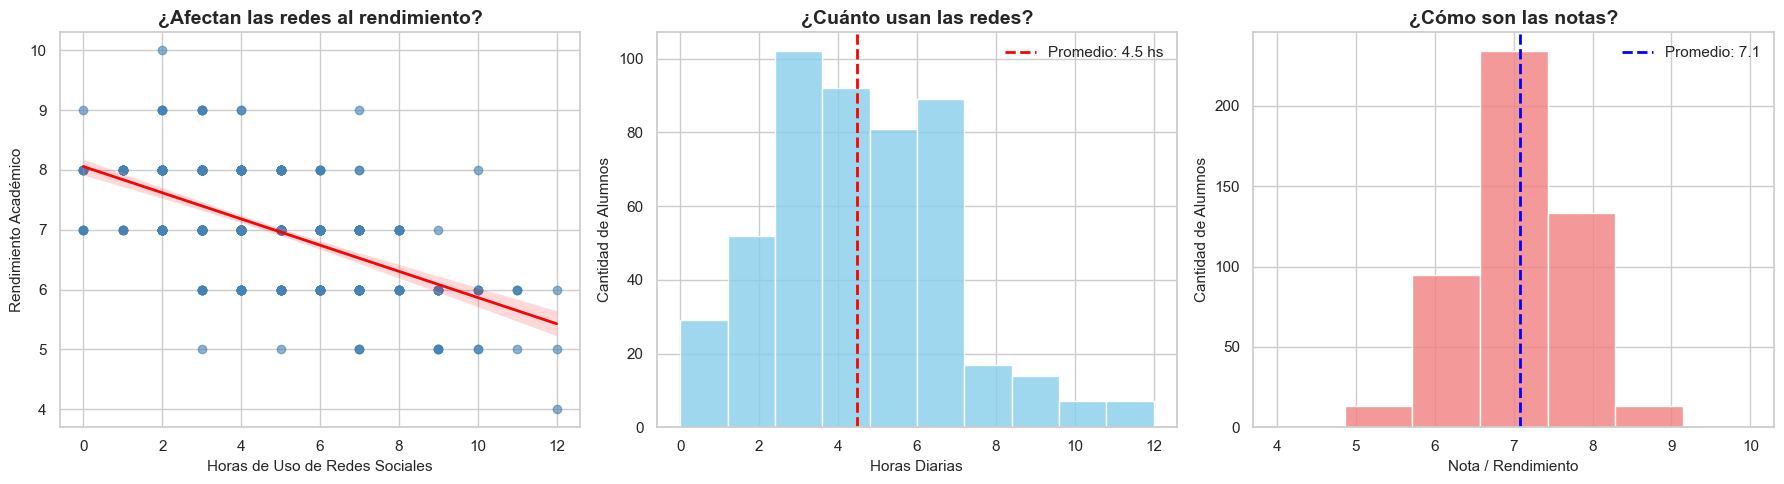


✓ Gráficos simplificados guardados como 'analisis_simplificado.png'


In [70]:
# 1. Configuramos un estilo limpio y moderno sin tanto código manual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: La Relación Principal ---
# sns.regplot hace el scatter y la línea de regresión automáticamente
sns.regplot(x=x, y=y, ax=axes[0], 
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'}, 
            line_kws={'color': 'red', 'linewidth': 2})

axes[0].set_title('¿Afectan las redes al rendimiento?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Horas de Uso de Redes Sociales', fontsize=11)
axes[0].set_ylabel('Rendimiento Académico', fontsize=11)


# --- GRÁFICO 2: Distribución de Horas ---
sns.histplot(x=x, bins=10, ax=axes[1], color='skyblue', alpha=0.8, edgecolor='white')
axes[1].axvline(x.mean(), color='red', linestyle='--', linewidth=2, label=f'Promedio: {x.mean():.1f} hs')

axes[1].set_title('¿Cuánto usan las redes?', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Horas Diarias', fontsize=11)
axes[1].set_ylabel('Cantidad de Alumnos', fontsize=11)
axes[1].legend()


# --- GRÁFICO 3: Distribución del Rendimiento ---
sns.histplot(x=y, bins=7, ax=axes[2], color='lightcoral', alpha=0.8, edgecolor='white')
axes[2].axvline(y.mean(), color='blue', linestyle='--', linewidth=2, label=f'Promedio: {y.mean():.1f}')

axes[2].set_title('¿Cómo son las notas?', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Nota / Rendimiento', fontsize=11)
axes[2].set_ylabel('Cantidad de Alumnos', fontsize=11)
axes[2].legend()


# Ajustamos espacios y guardamos
plt.tight_layout()
plt.savefig('analisis_simplificado.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos simplificados guardados como 'analisis_simplificado.png'")

# Visualización del análisis

En esta celda se muestran gráficos que completan el análisis numérico. La visualización ayuda a confirmar la dirección de la relación y a mostrar la distribución de cada variable.
